# pyNanoMatBuilder ↔ DebyeCalculator coupling

Minimal tutorial showing how to build a nanoparticle with **pyNanoMatBuilder** and compute its powder X-ray scattering pattern with **DebyeCalculator**(https://github.com/FrederikLizakJohansen/DebyeCalculator/tree/main).

This is a simple, one-off coupling example — it does **not** cover batch/dataset generation over many NPs.

**Required environment / kernel**: `debyecalculator_env`

Create your environment, for example with conda:

```bash
conda create -n debyecalculator_env python=3.11 -y
conda activate debyecalculator_env
```

Install the dependencies:

```bash
pip install -r requirements-debye.txt -e . 
```

Register the kernel if not already done:
```bash
python -m ipykernel install --user --name debyecalculator_env --display-name "Python (debyecalculator_env)"
```

Make sure this notebook is running on the **debyecalculator_env** kernel before executing the cells below.



## 1. Setup

In [2]:
from debyecalculator import DebyeCalculator
from pyNanoMatBuilder import platonicNPs as pNP
import matplotlib.pyplot as plt
from pyNanoMatBuilder import utils as pyNMBu
import numpy as np

## 2. Build a nanoparticle with pyNanoMatBuilder

In [3]:
# Gold icosahedron, ~4 nm — any other pyNanoMatBuilder shape class works too
AuNP = pNP.regIco(element='Au', Rnn=2.885, nShell=5,
                  postAnalyzis=True, thresholdCoreSurface=1,
                  skipSymmetryAnalyzis=True, aseView=False, noOutput=True)

pyNMBu.write("coords/AuNP_debye.xyz", AuNP.NP)  

print(f"{len(AuNP.NP)} atoms, circumscribed diameter = "
      f"{AuNP.radiusCircumscribedSphere * 2 / 10:.2f} nm")

561 atoms, circumscribed diameter = 2.74 nm


## 3. Compute the scattering pattern 

X-ray scattering techniques are powerful tools to probe nanoparticle structure. An incident X‑ray beam is scattered by the sample; the scattered intensity is measured as a function of the magnitude Q of the scattering vector (Q = 4π sinθ / λ, with 2θ the scattering angle and λ the wavelength). At small Q (typically Q 
technique is called SAXS (small‑angle X‑ray scattering) and yields information on size, shape and polydispersity; at larger Q (Q ≳ 1 $Å−1$) it is called WAXS (wide-angle X-ray scattering) and it probes atomic arrangements.


The total coherent scattering is given by the Debye formula. Written explicitly:


Equation (1) — full Debye formula
$$
I(Q) \;=\; \sum_{i=1}^{N}\sum_{j=1}^{N} f_i(Q)\,f_j(Q)\,\frac{\sin\bigl(Q\,r_{ij}\bigr)}{Q\,r_{ij}}
$$

- `DebyeCalculator` implements the general Debye formula (Equation 1). The most precise method but scales as $O(N^2)$; use it for relatively small nanoparticles. 
For large particles, we recommend using `pyAUSAXS` that indroduces the efficient approximation of an histogram of interatomic distances. In this case, please refer to `pyNMB-pyausaxs-coupling.ipynb` notebook. 


- `DebyeCalculator` also provides  the structure Function $S(Q)$, the reduced structure function $F(Q)$, and the reduced pair distribution function  $G(r)$.

- In `DebyeCalculator`, GPU with Torch and CUDA can be used for computation acceleration.


CUDA available: True


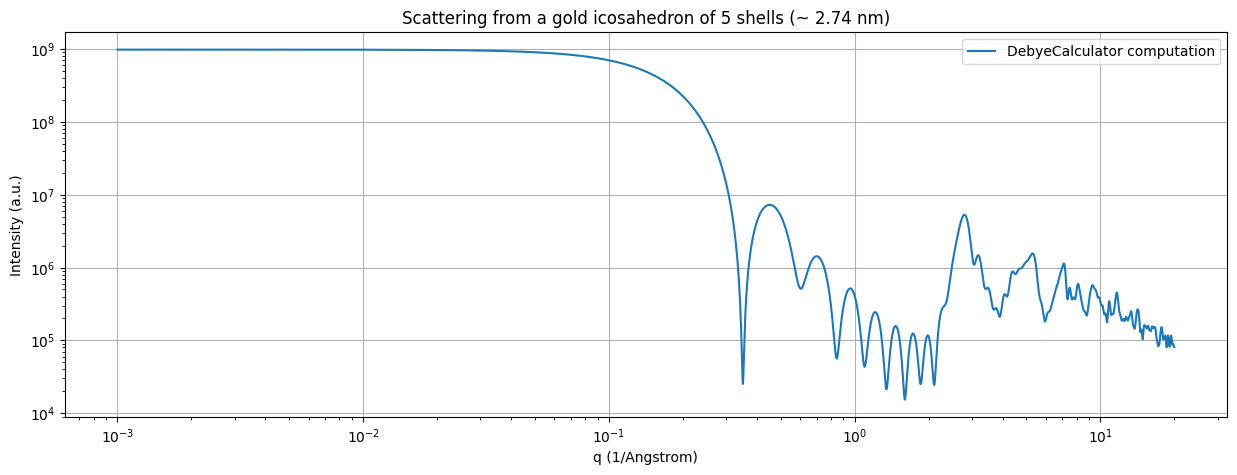

In [5]:
# Find an official demo in https://github.com/FrederikLizakJohansen/DebyeCalculator/blob/main/Demo.ipynb, this one is adapted to our data
# The DebyeCalculator package supports GPU acceleration using PyTorch with CUDA
import torch
print("CUDA available:", torch.cuda.is_available())
calc = DebyeCalculator(device='cuda') # or cpu if you don't have it

# Instantiate the DebyeCalculator class with the q range
calc = DebyeCalculator(qmin = 0.001, qmax = 20, qstep = 0.001, biso = 0)

# Path to your file (.xyz and .cif supported)
path = "coords/AuNP_debye.xyz"

# Function that computes the scattered intensity (takes in account the atomic form factors of all compounds)
q, iq = calc.iq(path) # gr, fq, sq also exist (cf Demo.ipynb of the package)
np.savetxt("coords/AuNP_debye.txt", np.column_stack((q, iq)), header="q (1/Angstrom)    Intensity (a.u.)")

# Plot
plt.figure(figsize=(15,5))
plt.loglog(q, iq, label="DebyeCalculator computation")
plt.yscale('log')
plt.xlabel('q (1/Angstrom)')
plt.ylabel('Intensity (a.u.)')
plt.title('Scattering from a gold icosahedron of 5 shells (~ 2.74 nm)')
plt.legend()
plt.grid()
plt.show()
plt.close()

*Note: This simulation corresponds to icosahedrons with a one specific size. Note that, experimentally, nanoparticles in the sample do not all have exactly the same size. There is a size distribution, and the total measured intensity is a weighted average over the size distribution. Please refer to `pyNMB-tutorials.ipynb` to see how to generate this size polydispersity.*

## 4. Normalization to compare pyAUSAXS and DebyeCalculator patterns

To compare the scattering patterns from pyAUSAXS and DebyeCalculator, normalize both datasets such that $I(q=0) = 1$.

**Normalization factors** (monoatomic case):

**pyAUSAXS:**
$$N_{\text{pyAUSAXS}} = \frac{1.6 \times 10^{-4}}{Z^2 N^2}$$

**DebyeCalculator:**
$$N_{\text{DebyeCalculator}} = \frac{2}{Z^2 N^2}$$

where:
- $Z$ = atomic number of the element
- $N$ = total number of atoms

For polyatomic systems, adapt the formula by replacing $Z^2$ and $N^2$ with appropriate averages or sums over atomic species.